# Description

Large-scale multi-detector ElectroMagnetic Universal Representation of Showers - data playground

https://zenodo.org/records/17045562

* $K$: number of events
    - dataset FCCee\{ALLEGRO,CLD\}: ~100000
    - dataset ODD: ~
    - dataset Par04\{SciPb,SiW\}: ~
* $V$: total number of voxels
    - dataset *any: 6480, 45 layers (N), 16 ang splits (P), 9 rad splits (R) 
* $E_i,\quad i=1,\dots,K$: incident energy
* $\alpha_i$: angle of entrance
* $pid_j$: particle id
* $\pmb{x}_{i}\in \mathbb{R}^V$ energy deposits across voxels
* `showers` numpy array of shape (N, R, P)
* `incident_energy` numpy array of shape (K, 1)
* `incident_phi` numpy array of shape (K, 1)
* `incident_theta` numpy array of shape (K, 1)

$$
\pmb{E} = 
\begin{bmatrix}
E_1\\
E_2\\
\vdots\\
E_K
\end{bmatrix},
\ \ \ 
X = 
\begin{bmatrix}
\ \pmb{x}^t_1 \\
\ \pmb{x}^t_2 \\
\vdots\\
\ \pmb{x}^t_K 
\end{bmatrix}
$$

$$
\pmb{x}_i = f(E_i,\ \alpha_i ;\ pid_j,\ geometry_j),\quad i=1,..,K,\quad j=1,...,4
$$

In [1]:
!git clone https://github.com/OzAmram/CaloChallenge.git

fatal: destination path 'CaloChallenge' already exists and is not an empty directory.


In [17]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import sys
from utilities import LemursDataset

filename = "../LEMURS_FCCeeALLEGRO_gamma_100kEvents_1GeV100GeV_GPSflat_part1.h5"
n_events = 1000

ds = LemursDataset(filename, showers_key="showers", energies_key="incident_energy",
                   voxel_shape=(9, 16, 45), data_slice=slice(0, n_events))
showers           = ds.showers    # (n_events, 9, 16, 45)  → (K, R, P, N)
incident_energies = ds.energies   # (n_events,) MeV

df = pd.DataFrame(showers.flatten())
df.describe()

,0
count,6.480000e+06
mean,1.100166e+00
std,2.777194e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,8.875625e-01
max,5.002126e+01


# 3D scatter

In [13]:
from utilities import plot_shower_3d

i_idx     = 0
threshold = 1  # MeV

shower3d = showers[i_idx, :, :, :]
plot_shower_3d(shower3d, i_idx=i_idx, incident_energy=incident_energies[i_idx], threshold=threshold)

# Z-profiles

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: title={'center': 'MeV'}>,
        <Axes: title={'center': 'log(MeV)'}>], dtype=object))

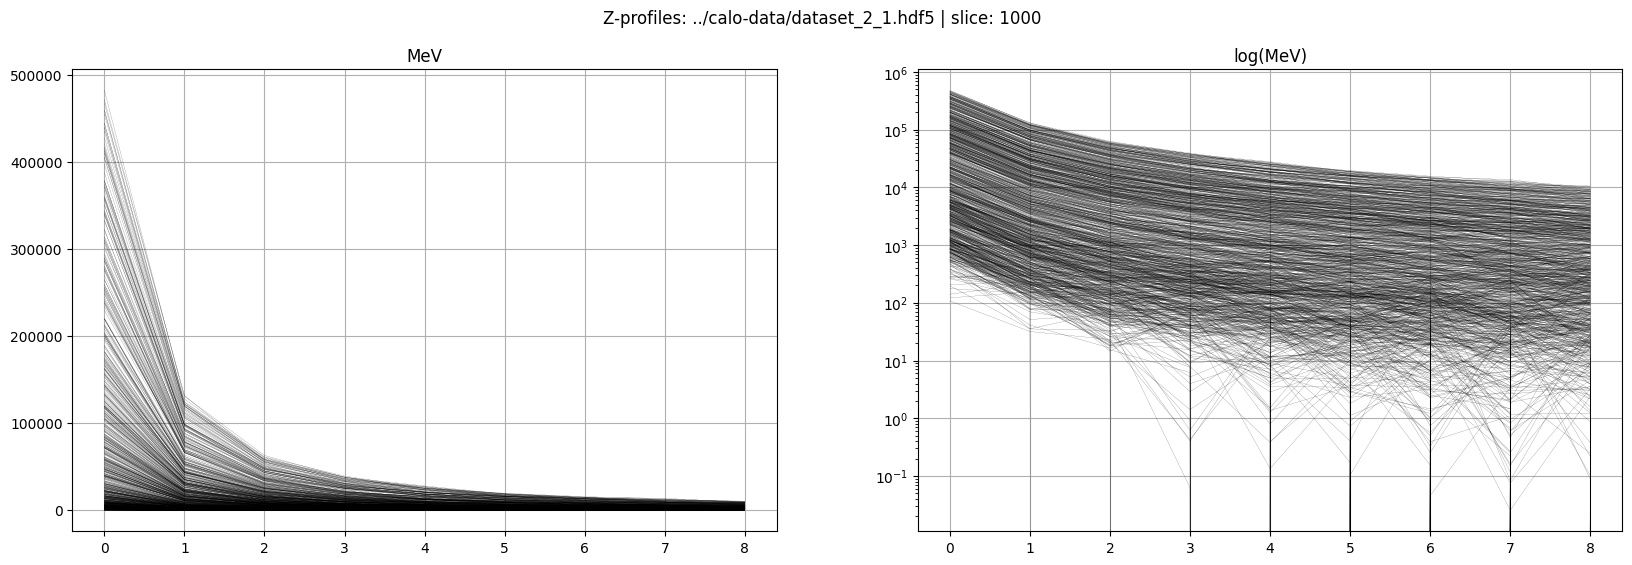

In [14]:
from utilities import plot_z_profiles
i_idcs = 1000
plot_z_profiles(showers, filename=filename, i_idcs=i_idcs)

# Mesh3d
Requested by @arampatzis

In [15]:
from utilities import plot_layer_mesh3d

shower3d = showers[0, :, :, :]
layers   = list(range(15))
plot_layer_mesh3d(shower3d, layers=layers, n_cols=5)

IndexError: index 9 is out of bounds for axis 2 with size 9